<a href="https://colab.research.google.com/github/EJUAREZROM/cloud-run-microservice-template-python/blob/main/Actividad_2_P1_A_M_G_regresion_online_river_trumpapproval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regresión en línea con River: de la analítica descriptiva al aprendizaje incremental

**Basado en:** Korstanje, J. (2023). *Machine Learning for Streaming Data with Python*. Packt Publishing, y documentación introductoria de River.

## Objetivos de la actividad

- Comprender la diferencia entre aprendizaje *offline* y aprendizaje *online*.
- Explorar descriptivamente un dataset con estructura temporal.
- Implementar regresión en línea con River.
- Evaluar el modelo mediante **evaluación progresiva**.
- Comparar conceptualmente un modelo batch con un modelo incremental.

## Idea central

En aprendizaje tradicional, el modelo se entrena con todos los datos disponibles.  
En aprendizaje en línea, el modelo recibe observaciones una por una:

1. Predice.
2. Se compara con el valor real.
3. Aprende de la nueva observación.

Este flujo es especialmente importante cuando los datos cambian con el tiempo.

## 1. Instalación e importación de librerías

In [ ]:

!pip install --force-reinstall --no-cache-dir numpy==1.26.4 river==0.21.2 --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 73.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 131.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 162.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 48.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 77.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 123.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.9/229.9 kB 186.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.1/510.1 kB 75.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 90.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requi

In [ ]:
import os
os._exit(0) #Reinicio

In [ ]:
import numpy as np
import river

print("NumPy:", np.__version__)
print("River:", river.__version__)

NumPy: 1.26.4
River: 0.21.2


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from river import datasets
from river import linear_model
from river import metrics
from river import evaluate

from sklearn.linear_model import LinearRegression as SKLinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

## 2. Carga del dataset TrumpApproval

River incluye un dataset llamado `TrumpApproval`, construido a partir de datos de aprobación presidencial.  
El objetivo es predecir el valor de aprobación estimado por FiveThirtyEight usando como variables distintas mediciones de encuestadoras.

Aunque el dataset no es enorme, es útil porque tiene una lógica temporal: las observaciones pueden leerse como un flujo de datos.

In [ ]:
dataset = datasets.TrumpApproval()
dataset

Donald Trump approval ratings.

This dataset was obtained by reshaping the data used by FiveThirtyEight for analyzing Donald
Trump's approval ratings. It contains 5 features, which are approval ratings collected by
5 polling agencies. The target is the approval rating from FiveThirtyEight's model. The goal of
this task is to see if we can reproduce FiveThirtyEight's model.

    Name  TrumpApproval                                                               
    Task  Regression                                                                  
 Samples  1,001                                                                       
Features  6                                                                           
  Sparse  False                                                                       
    Path  /usr/local/lib/python3.12/dist-packages/river/datasets/trump_approval.csv.gz

Convertimos el flujo de River en un `DataFrame` únicamente para hacer analítica descriptiva.

In [ ]:
data = []

for x, y in dataset:
    row = x.copy()
    row["target"] = y
    data.append(row)

df = pd.DataFrame(data)

print("Dimensiones del dataset:", df.shape)
display(df.head(8))

Dimensiones del dataset: (1001, 7)


,ordinal_date,gallup,ipsos,morning_consult,rasmussen,you_gov,target
0,736389,43.843213,46.199250,48.318749,44.104692,43.636914,43.75505
1,736390,43.843213,46.199250,48.318749,46.104692,41.636914,43.71027
2,736391,43.843213,46.437346,48.318749,47.104692,41.636914,43.90226
3,736392,43.843213,46.437346,48.318749,47.104692,41.636914,43.90226
4,736393,43.843213,46.437346,48.318749,47.104692,41.636914,43.93693
5,736394,44.843213,46.437346,48.318749,46.104692,41.636914,44.08371
6,736395,43.843213,46.920679,48.318749,45.104692,41.636914,44.34550
7,736396,42.843213,46.920679,48.318749,43.104692,42.636914,44.33974


In [ ]:
df.tail(8)

,ordinal_date,gallup,ipsos,morning_consult,rasmussen,you_gov,target
993,737382,41.843213,41.570679,38.318749,42.104692,45.636914,41.285518
994,737383,43.843213,40.570679,36.318749,42.104692,39.636914,41.351546
995,737384,43.843213,40.570679,36.318749,40.104692,42.636914,41.876382
996,737385,43.843213,40.570679,38.818749,40.104692,43.636914,41.891828
997,737386,43.843213,40.570679,38.818749,40.104692,43.636914,41.891828
998,737387,43.843213,40.570679,38.818749,40.104692,43.636914,41.891828
999,737388,43.843213,40.570679,38.818749,38.104692,41.636914,41.725397
1000,737389,43.843213,40.570679,37.818749,40.104692,41.636914,41.740203


## 3. Analítica descriptiva inicial

In [ ]:
print("Información general:")
display(df.info())

print("\nResumen estadístico:")
display(df.describe())

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ordinal_date     1001 non-null   int64  
 1   gallup           1001 non-null   float64
 2   ipsos            1001 non-null   float64
 3   morning_consult  1001 non-null   float64
 4   rasmussen        1001 non-null   float64
 5   you_gov          1001 non-null   float64
 6   target           1001 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 54.9 KB


None


Resumen estadístico:


,ordinal_date,gallup,ipsos,morning_consult,rasmussen,you_gov,target
count,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000
mean,736889.000000,40.785770,40.693310,41.069130,40.738059,40.789766,40.754581
std,289.108111,2.574674,2.618851,2.651570,2.654891,1.919642,1.711387
min,736389.000000,33.843213,34.670679,35.318749,32.104692,34.636914,36.403140
25%,736639.000000,38.843213,39.070679,39.318749,39.104692,39.636914,39.504430
50%,736889.000000,40.843213,40.570679,40.318749,41.104692,40.636914,41.385200
75%,737139.000000,42.843213,41.804012,42.318749,43.104692,42.136914,42.089690
max,737389.000000,46.843213,48.870679,50.318749,47.104692,49.336914,44.766690


## Una observación interesante del dataset

El **`target` presenta menor variabilidad** que las encuestas individuales:

- Desviación estándar del `target`: ≈ 1.71  
- Desviaciones estándar de encuestas: ≈ 2.5–2.6  

Esto sugiere que el `target` funciona como una **estimación agregada o suavizada** de las encuestas.

En otras palabras:
- Las encuestas individuales son más “ruidosas”
- El `target` es más estable

### 3.1 Distribución de la variable objetivo

La variable `target` representa el valor de aprobación que queremos predecir.

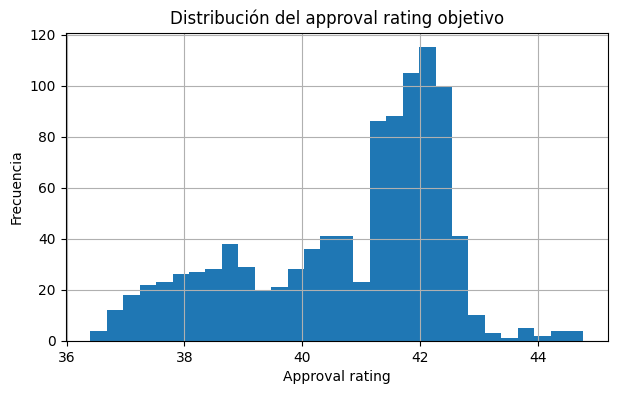

In [ ]:
plt.figure(figsize=(7, 4))
df["target"].hist(bins=30)
plt.title("Distribución del approval rating objetivo")
plt.xlabel("Approval rating")
plt.ylabel("Frecuencia")
plt.show()

## Sobre la distribución del approval rating

El histograma muestra que el `target` (approval rating) se concentra principalmente entre valores de **40 y 43**.

- La distribución es **unimodal** (una sola “montaña” principal).
- Existe una ligera **asimetría hacia valores bajos** (cola hacia la izquierda).

### Implicación

Esto indica que el problema tiene **baja variabilidad**, por lo que:

- Es difícil obtener valores altos de **R²**
- Incluso modelos simples pueden tener un **MAE bajo**

El reto del modelo no será predecir valores extremos, sino **ajustar pequeñas variaciones dentro de un rango reducido**.

### 3.2 Evolución temporal del target

La variable `ordinal_date` permite ordenar los datos en el tiempo.  
Esto es importante porque el aprendizaje online intenta respetar el orden en que llegan las observaciones.

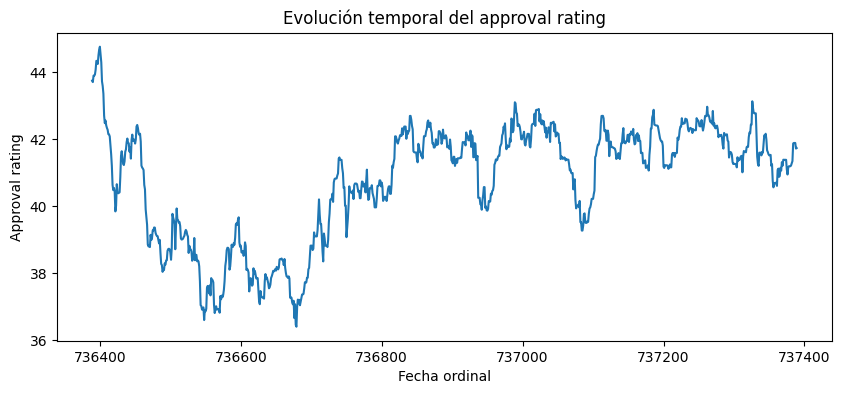

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(df["ordinal_date"], df["target"])
plt.title("Evolución temporal del approval rating")
plt.xlabel("Fecha ordinal")
plt.ylabel("Approval rating")
plt.show()

### 3.3 Relación entre encuestadoras y target

Podemos comparar visualmente algunas variables con la variable objetivo.

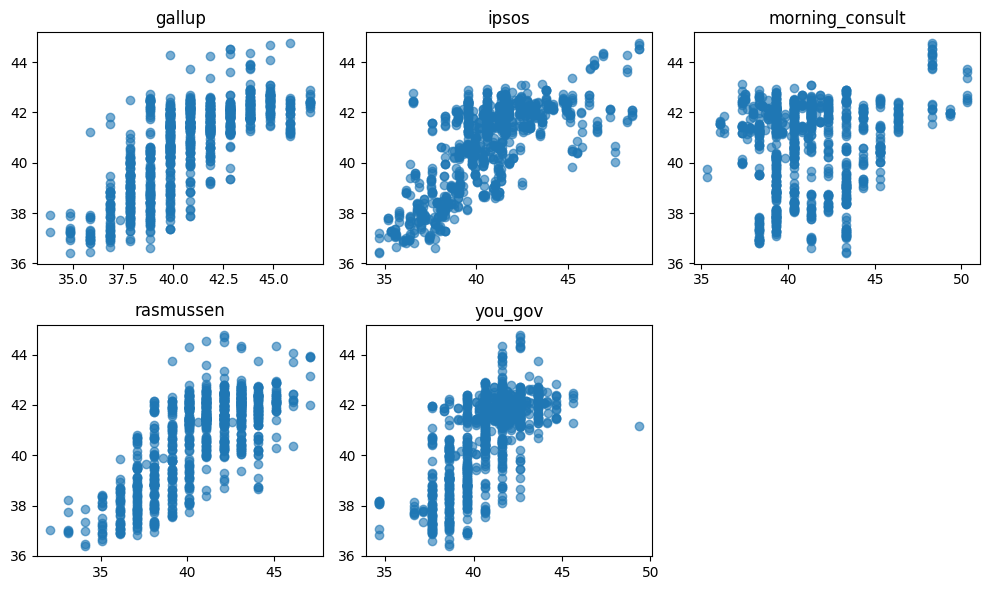

In [ ]:
features_to_plot = ["gallup", "ipsos", "morning_consult", "rasmussen", "you_gov"]

fig, axes = plt.subplots(2, 3, figsize=(10, 6))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    axes[i].scatter(df[col], df["target"], alpha=0.6)
    axes[i].set_title(col)

# quitar subplot vacío
axes[-1].axis('off')

plt.tight_layout()
plt.show()

### 3.4 Matriz de correlación

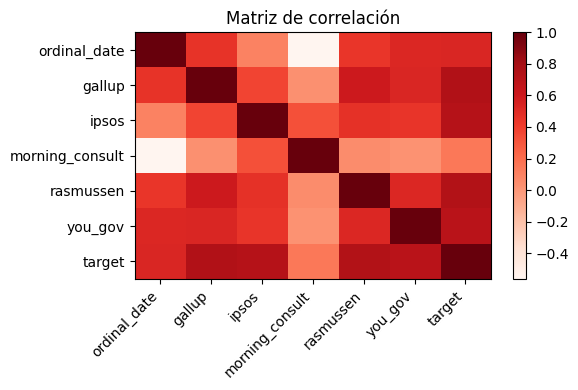

In [ ]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(6, 4))
plt.imshow(corr, cmap='Reds', aspect="auto")  #  mapa rojo
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

#display(corr)

La matriz muestra que el `target` tiene una **alta correlación positiva** con todas las encuestas (`gallup`, `ipsos`, `rasmussen`, etc.).

- Las encuestas están **fuertemente correlacionadas entre sí**.
- El `target` también está altamente correlacionado con ellas.
- `ordinal_date` tiene menor relación directa.

Entonces el modelo no necesitará descubrir patrones complejos, sino: **aprender a combinar variables altamente relacionadas para aproximar el target**

Esto sugiere que modelos simples podrían funcionar bien en este problema.

## 4. Interpretación antes de modelar

Antes de entrenar modelos, conviene notar lo siguiente:

- El problema es de **regresión**, porque queremos predecir un valor numérico.
- Las variables de entrada son mediciones de distintas fuentes.
- El target representa una estimación agregada o modelada.
- El orden temporal importa: no es lo mismo evaluar mezclando datos que evaluarlos conforme llegan.

Esta última idea es la que justifica usar evaluación progresiva.

## 5. Modelo offline (batch learning) como referencia

Primero entrenamos un modelo tradicional con scikit-learn.  
Este enfoque divide los datos en entrenamiento y prueba, entrena con todo el conjunto de entrenamiento y evalúa al final.

In [ ]:
# Separación de variables
X = df.drop(columns=["target"])
y = df["target"]

# Split respetando el orden temporal
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, shuffle=False
)

print("Tamaño entrenamiento:", X_train.shape)
print("Tamaño prueba:", X_test.shape)

Tamaño entrenamiento: (700, 6)
Tamaño prueba: (301, 6)


##  Variables del modelo

- **Variable objetivo (y):**
  - `target` → approval rating estimado por FiveThirtyEight.

- **Variables predictoras (X):**
  - `gallup`, `ipsos`, `morning_consult`, `rasmussen`, `you_gov`
  - `ordinal_date` (tiempo)

El modelo intentará aprender:

encuestas individuales → approval final

Es decir, cómo combinar distintas encuestas para aproximar el valor del `target`.

## Baseline: predicción con la media

Antes de entrenar un modelo, usamos un **baseline** simple:  
predecir siempre la **media del conjunto de entrenamiento**.

Esto sirve como punto de referencia para evaluar si el modelo realmente aprende algo.

- **MAE** mide el error promedio de esta predicción simple.
- **R²** indica qué tan mejor (o peor) es respecto a usar la media.

Un buen modelo debería **mejorar estos valores**.

In [ ]:
# Baseline: predecir siempre la media del entrenamiento
from sklearn.metrics import mean_absolute_error, r2_score

baseline_pred = [y_train.mean()] * len(y_test)

mae_baseline = mean_absolute_error(y_test, baseline_pred)
r2_baseline = r2_score(y_test, baseline_pred)

print("Baseline (media):")
print(f"MAE: {mae_baseline:.4f}")
print(f"R²: {r2_baseline:.4f}")

Baseline (media):
MAE: 1.5047
R²: -4.8873


In [ ]:
from sklearn.linear_model import LinearRegression as SKLinearRegression

# Entrenamiento batch
offline_model = SKLinearRegression()
offline_model.fit(X_train, y_train)

# Predicciones
offline_preds = offline_model.predict(X_test)

# Evaluación
mae_offline = mean_absolute_error(y_test, offline_preds)
r2_offline = r2_score(y_test, offline_preds)

print("Modelo offline (Regresión lineal):")
print(f"MAE: {mae_offline:.4f}")
print(f"R²: {r2_offline:.4f}")

Modelo offline (Regresión lineal):
MAE: 0.5056
R²: 0.0949


In [ ]:
import pandas as pd

comparison = pd.DataFrame({
    "Modelo": ["Baseline (media)", "Offline (Linear Regression)"],
    "MAE": [mae_baseline, mae_offline],
    "R²": [r2_baseline, r2_offline]
})

display(comparison)

,Modelo,MAE,R²
0,Baseline (media),1.504661,-4.887344
1,Offline (Linear Regression),0.505624,0.094943


## Resultado del modelo offline

Entrenamos un modelo de regresión lineal con todos los datos de entrenamiento (*batch*) y lo evaluamos sobre datos futuros.

- **MAE ≈ 0.51** → el error promedio es bajo, el modelo predice razonablemente bien.
- **R² ≈ 0.09** → el modelo explica poca variabilidad adicional respecto a la media.

Interpretación: El modelo mejora claramente al baseline, pero la baja variabilidad del dataset limita el valor de R².

### Nota conceptual

Usamos `shuffle=False` porque este dataset tiene una lógica temporal.  
Si mezcláramos aleatoriamente los datos, estaríamos rompiendo parcialmente la idea de flujo temporal.

## 6. Regresión lineal online con River

Ahora implementamos un modelo de regresión lineal incremental.  
El modelo no recibe todo el dataset de una vez. En cada paso:

1. Predice con el estado actual.
2. Se actualiza la métrica.
3. Aprende de la observación.

A este proceso se le conoce como **evaluación progresiva**.

In [ ]:
from river import compose
from river import preprocessing
from river import optim

In [ ]:
# ============================================================
#  Regresión en línea con River (evaluación progresiva)
# ============================================================

# 1️ Cargamos el dataset en formato de flujo (stream)
#     Cada iteración devuelve una observación (x) y su valor objetivo (y)
from river import datasets
dataset = datasets.TrumpApproval()

# ============================================================
# 2️ Definición del modelo online
# ============================================================

from river import compose, preprocessing, linear_model, optim

# Se construye un pipeline con dos componentes:
# 1) StandardScaler: normaliza las variables de entrada en línea
#    (calcula media y varianza de forma incremental)
# 2) LinearRegression: modelo lineal entrenado con SGD (descenso por gradiente)

model = compose.Pipeline(
    preprocessing.StandardScaler(),  # Escalado incremental de variables
    linear_model.LinearRegression(
        optimizer=optim.SGD(lr=0.001)  # Tasa de aprendizaje pequeña para estabilidad
    )
)


In [ ]:

# ============================================================
# 3️ Inicialización de métricas de evaluación
# ============================================================

from river import metrics

# MAE: Error absoluto medio (interpretación directa en unidades del problema)
# R²: Proporción de varianza explicada (mejora respecto a la media)
metric_mae_lr = metrics.MAE()
metric_r2_lr = metrics.R2()

In [ ]:
# ============================================================
# Ciclo de aprendizaje online con evaluación progresiva
# ============================================================

# Guardaremos los valores reales y predichos para graficarlos después
y_true_lr = []
y_pred_lr = []

# El dataset se recorre como un flujo: una observación a la vez
for i, (x, y) in enumerate(dataset):

    # 1. El modelo predice ANTES de aprender de esta observación
    #    Usa únicamente lo que ha aprendido de observaciones anteriores.
    y_hat = model.predict_one(x)

    # 2. Se evalúa la predicción comparándola con el valor real
    #    Aquí todavía no se ha entrenado con esta fila.
    metric_mae_lr.update(y, y_hat)
    metric_r2_lr.update(y, y_hat)

    # 3. Ahora el modelo aprende de esta observación
    #    Ajusta sus parámetros para mejorar en futuras predicciones.
    model.learn_one(x, y)

    # 4. Guardamos los valores para visualizarlos después
    y_true_lr.append(y)
    y_pred_lr.append(y_hat)

    # 5. Mostramos las primeras iteraciones para observar el proceso
    if i < 5:
        print(f"Iteración {i+1}")
        print(f"Real: {y:.3f} | Predicción antes de aprender: {y_hat:.3f}")
        print("-" * 40)

Iteración 1
Real: 43.755 | Predicción antes de aprender: 0.000
----------------------------------------
Iteración 2
Real: 43.710 | Predicción antes de aprender: 0.875
----------------------------------------
Iteración 3
Real: 43.902 | Predicción antes de aprender: 2.246
----------------------------------------
Iteración 4
Real: 43.902 | Predicción antes de aprender: 3.489
----------------------------------------
Iteración 5
Real: 43.937 | Predicción antes de aprender: 4.559
----------------------------------------


In [ ]:

# ============================================================
# 5️ Resultados finales
# ============================================================

print("MAE online:", metric_mae_lr)
print("R² online:", metric_r2_lr)

MAE online: MAE: 2.321971
R² online: R2: -11.251303


El modelo predice bastante bien en términos absolutos (MAE bajo), pero como el approval no cambia mucho, tampoco hay mucha variabilidad que explicar, por eso el R² es moderado.

In [ ]:
from river import datasets, neighbors, metrics

dataset = datasets.TrumpApproval()

model_knn = neighbors.KNNRegressor()
metric_mae_knn = metrics.MAE()
metric_r2_knn = metrics.R2()

y_true_knn = []
y_pred_knn = []

for x, y in dataset:
    y_hat = model_knn.predict_one(x)

    metric_mae_knn.update(y, y_hat)
    metric_r2_knn.update(y, y_hat)

    model_knn.learn_one(x, y)

    y_true_knn.append(y)
    y_pred_knn.append(y_hat)

print(metric_mae_knn)
print(metric_r2_knn)

MAE: 0.310353
R2: 0.303313


¿Por qué ocurre esto?

- La **regresión lineal online** aprende mediante descenso por gradiente (SGD), lo cual es sensible a:
  - la escala de los datos (especialmente `ordinal_date`)
  - la tasa de aprendizaje
  - las primeras observaciones (fase inestable)

- **KNN** no aprende una función global:
  - simplemente usa observaciones cercanas
  - se adapta mejor a relaciones no lineales
  - es más robusto en datasets pequeños y suaves como este

No todos los modelos funcionan igual en aprendizaje online:

- La regresión lineal requiere mayor cuidado (escala, hiperparámetros)
- KNN se adapta mejor de forma inmediata en este tipo de datos

## 7. Visualización de predicción online vs valor real

En aprendizaje online, es normal que las primeras predicciones sean débiles porque el modelo todavía no ha visto suficientes datos.

In [ ]:
# ============================================================
# Visualización: valor real vs predicciones online
# ============================================================

import matplotlib.pyplot as plt

def plot_online_predictions(y_true, y_pred, titulo="Predicción online vs valor real"):

    plt.figure(figsize=(10, 4))

    # Serie real
    plt.plot(y_true, label="Valor real", linewidth=2)

    # Predicción
    plt.plot(y_pred, label="Predicción online", alpha=0.75)

    plt.title(titulo)
    plt.xlabel("Observación en el flujo")
    plt.ylabel("Approval rating")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

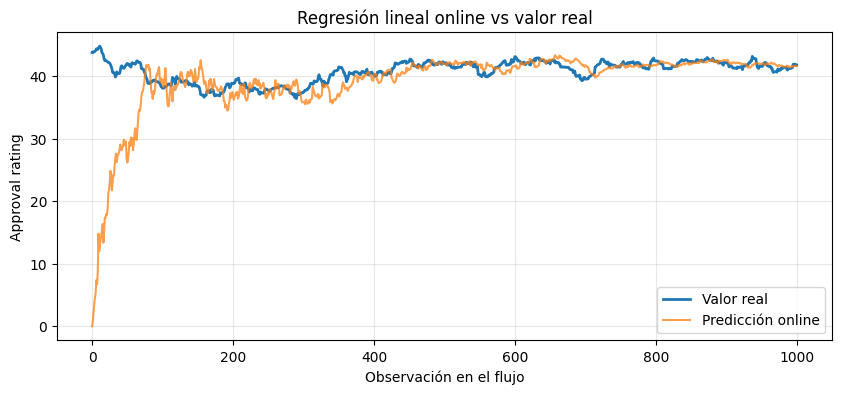

In [ ]:
plot_online_predictions(
    y_true_lr,
    y_pred_lr,
    "Regresión lineal online vs valor real"
)

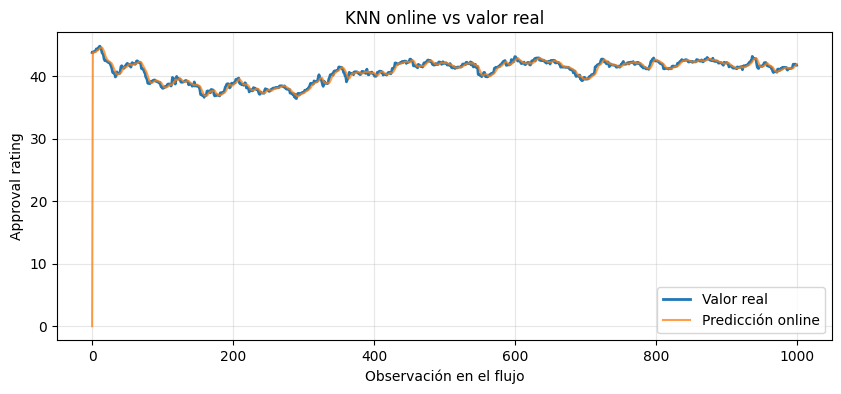

In [ ]:
plot_online_predictions(
    y_true_knn,
    y_pred_knn,
    "KNN online vs valor real"
)

El modelo de KNN falla al inicio porque no tiene información, pero en cuanto observa unos cuantos datos, empieza a seguir muy bien el comportamiento real.

También podemos visualizar el error absoluto a lo largo del flujo.

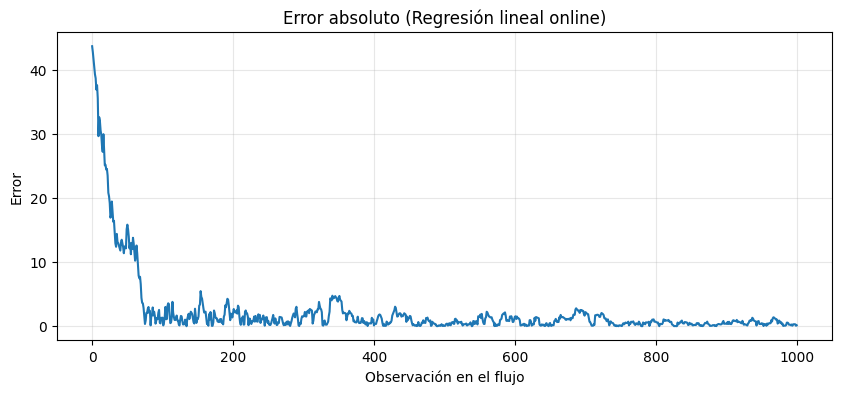

Error absoluto promedio (LR): 2.3220


In [ ]:
errors_lr = [abs(a - b) for a, b in zip(y_true_lr, y_pred_lr)]

plt.figure(figsize=(10, 4))
plt.plot(errors_lr)
plt.title("Error absoluto (Regresión lineal online)")
plt.xlabel("Observación en el flujo")
plt.ylabel("Error")
plt.grid(alpha=0.3)
plt.show()

print(f"Error absoluto promedio (LR): {sum(errors_lr)/len(errors_lr):.4f}")

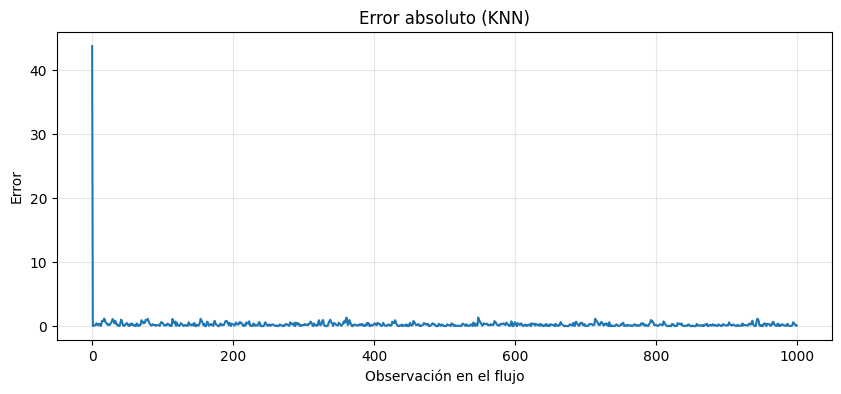

Error absoluto promedio: 0.3104


In [ ]:
errors_knn = [abs(a - b) for a, b in zip(y_true_knn, y_pred_knn)]

plt.figure(figsize=(10, 4))
plt.plot(errors_knn)
plt.title("Error absoluto (KNN)")
plt.xlabel("Observación en el flujo")
plt.ylabel("Error")
plt.grid(alpha=0.3)
plt.show()

print(f"Error absoluto promedio: {sum(errors_knn)/len(errors_knn):.4f}")

## 8. Uso de `evaluate.progressive_val_score`

River incluye una función que realiza automáticamente el ciclo de evaluación progresiva.

In [ ]:
from river import compose, preprocessing, linear_model, optim, metrics, datasets, evaluate

dataset = datasets.TrumpApproval()

model = compose.Pipeline(
    preprocessing.StandardScaler(),
    linear_model.LinearRegression(optimizer=optim.SGD(lr=0.001))
)

metric = metrics.MAE()

evaluate.progressive_val_score(dataset, model, metric)

MAE: 2.321971

## 9. Comparación conceptual: offline vs online

La comparación numérica debe interpretarse con cuidado porque los enfoques no responden exactamente a la misma pregunta.

- El modelo offline pregunta: “¿qué tan bien predigo un conjunto de prueba después de entrenar con un bloque de datos?”
- El modelo online pregunta: “¿qué tan bien predigo cada observación antes de aprender de ella?”

Por eso, en online learning no solo importa el resultado final, sino la evolución del desempeño.

In [ ]:
comparison = pd.DataFrame({
    "Modelo": [
        "Baseline (media)",
        "Offline (Linear Regression)",
        "Online (Linear Regression)",
        "Online (KNN)"
    ],
    "MAE": [
        mae_baseline,
        mae_offline,
        metric_mae_lr.get(),
        metric_mae_knn.get()
    ],
    "R²": [
        r2_baseline,
        r2_offline,
        metric_r2_lr.get(),
        metric_r2_knn.get()
    ]
})

display(comparison)

,Modelo,MAE,R²
0,Baseline (media),1.504661,-4.887344
1,Offline (Linear Regression),0.505624,0.094943
2,Online (Linear Regression),2.321971,-11.251303
3,Online (KNN),0.310353,0.303313


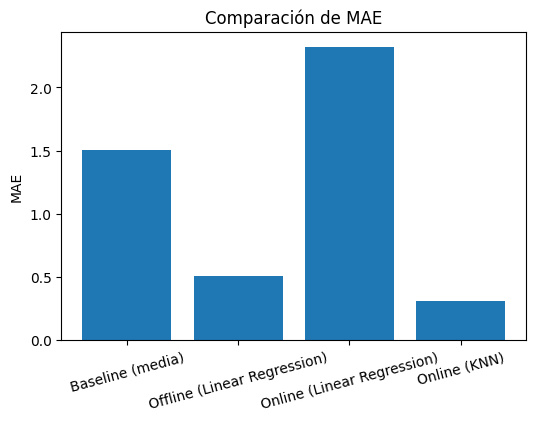

In [ ]:
plt.figure(figsize=(6, 4))
plt.bar(comparison["Modelo"], comparison["MAE"])
plt.title("Comparación de MAE")
plt.ylabel("MAE")
plt.xticks(rotation=15)
plt.show()

## 10. Recuperación de coeficientes del modelo online

Una ventaja de iniciar con regresión lineal es que podemos interpretar el modelo a partir de sus coeficientes.

In [ ]:
# ============================================================
# Coeficientes del modelo de regresión lineal (online)
# ============================================================

# Accedemos al modelo interno dentro del pipeline
lr_model = model[-1]

# Intercepto
print("Intercepto:", lr_model.intercept)

# Coeficientes
import pandas as pd

coeficientes = pd.Series(lr_model.weights)

print("\nCoeficientes (ordenados):")
display(coeficientes.sort_values(ascending=False))

Intercepto: 32.54384037280023

Coeficientes (ordenados):


,0
ordinal_date,5.108891
ipsos,0.125666
you_gov,0.049097
gallup,0.046162
morning_consult,-0.071929
rasmussen,-0.126134


## 11. Discusión final

Este ejercicio permite observar que el aprendizaje online no es simplemente una forma diferente de escribir código.  
Implica una forma distinta de pensar el modelado:

- El modelo no se entrena una sola vez.
- El modelo cambia conforme llegan nuevas observaciones.
- La evaluación se realiza respetando el orden del flujo.
- La métrica se actualiza durante el proceso.
- El aprendizaje es útil cuando los datos pueden cambiar con el tiempo.

## Preguntas para reflexionar

1. ¿Por qué no sería ideal mezclar aleatoriamente los datos en este ejercicio?
2. ¿Qué diferencia hay entre evaluar al final y evaluar progresivamente?
3. ¿Por qué un modelo online puede ser útil en contextos con datos cambiantes?
4. ¿Qué ventajas tiene usar regresión lineal para introducir online learning?
5. ¿Qué limitaciones tendría este enfoque si apareciera un cambio brusco en el comportamiento de los datos?

## 12. Cierre

La idea más importante es:

> En aprendizaje online, el modelo vive dentro del flujo de datos.

No solo predice.  
También aprende conforme el entorno cambia.